In [1]:
from sentence_transformers import SentenceTransformer
import random 
import matplotlib.pyplot as plt

# Load the pre-trained Sentence Transformers model
model = SentenceTransformer('all-MiniLM-L6-v2')

Matplotlib is building the font cache; this may take a moment.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\amond07\Workspace\ai-engineering\rag-learning\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\amond07\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [2]:
# List of sentences to encode
sentences = [
    "I am a happy person.",
    "I am a joyful person.",
    "I am a pessimistic person.",
    "I am not an optimistic person."
]

# Generate embeddings for the sentences
embeddings = model.encode(sentences)

In [3]:
print (embeddings.shape)
print (embeddings[:, :5]) # only the first 5 dimensions due to space constraints

(4, 384)
[[ 0.00464717  0.0665106   0.01479136 -0.0295569  -0.03556164]
 [ 0.03454594  0.05649192  0.00730663 -0.07299507 -0.06663919]
 [ 0.06152032  0.05317357  0.0178834   0.03482828 -0.03031245]
 [ 0.02471697  0.02527614 -0.00175563  0.0208723  -0.03713484]]


In [4]:
similarity_matrix = model.similarity(embeddings, embeddings)
print (similarity_matrix)

tensor([[1.0000, 0.8151, 0.3864, 0.5210],
        [0.8151, 1.0000, 0.3383, 0.4128],
        [0.3864, 0.3383, 1.0000, 0.7047],
        [0.5210, 0.4128, 0.7047, 1.0000]])


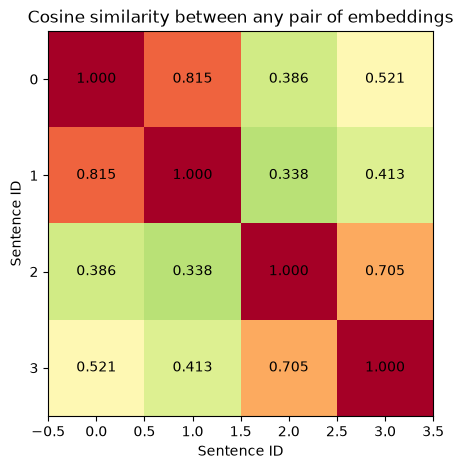

In [6]:
plt.figure(figsize=(5, 5))
plt.imshow(
    similarity_matrix, cmap='RdYlGn_r', interpolation='nearest', vmin=0, vmax=1
)
plt.title('Cosine similarity between any pair of embeddings')
plt.xlabel('Sentence ID')
plt.ylabel('Sentence ID')
plt.yticks([0, 1, 2, 3])

# Add text annotations
for i in range(len(similarity_matrix)):
    for j in range(len(similarity_matrix)):
        plt.text(j, i, f'{similarity_matrix[i][j]:.3f}', 
                ha='center', va='center', color='black')

plt.show()

In [7]:
# generate two random integers between 0 and 384
rand1 = random.randint(0, 384)
rand2 = random.randint(0, 384)

if rand1 > rand2:
    rand1, rand2 = rand2, rand1

print (f"Using semantic dimensions {rand1} to {rand2}")

similarity_matrix = model.similarity(
    embeddings[:, rand1:rand2], embeddings[:, rand1:rand2]
)
print (similarity_matrix)

Using semantic dimensions 55 to 180
tensor([[1.0000, 0.8144, 0.3974, 0.5716],
        [0.8144, 1.0000, 0.3091, 0.4465],
        [0.3974, 0.3091, 1.0000, 0.7091],
        [0.5716, 0.4465, 0.7091, 1.0000]])


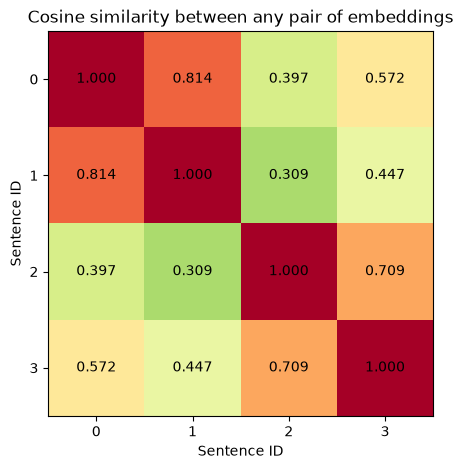

In [9]:
plt.figure(figsize=(5, 5))
plt.imshow(
    similarity_matrix, cmap='RdYlGn_r', interpolation='nearest', vmin=0, vmax=1
)
plt.title('Cosine similarity between any pair of embeddings')
plt.xlabel('Sentence ID')
plt.ylabel('Sentence ID')
plt.yticks([0, 1, 2, 3])
plt.xticks([0, 1, 2, 3])

# Add text annotations
for i in range(len(similarity_matrix)):
    for j in range(len(similarity_matrix)):
        plt.text(j, i, f'{similarity_matrix[i][j]:.3f}', 
                ha='center', va='center', color='black')

plt.show()